In [4]:
from google.colab import files
import pandas as pd

# This will open a file picker — select your train.csv
uploaded = files.upload()

df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
print("Dataset loaded!")
print(df.shape)
df.head()

Saving archive.zip to archive (1).zip
Dataset loaded!
(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nLoan Status Distribution:")
print(df['Loan_Status'].value_counts())
print("\nY = Approved | N = Not Approved")

Shape: (614, 13)

Column Names:
 ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Y = Approved | N = Not Approved


In [6]:
# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_686/2302762720.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_686/2302762720.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

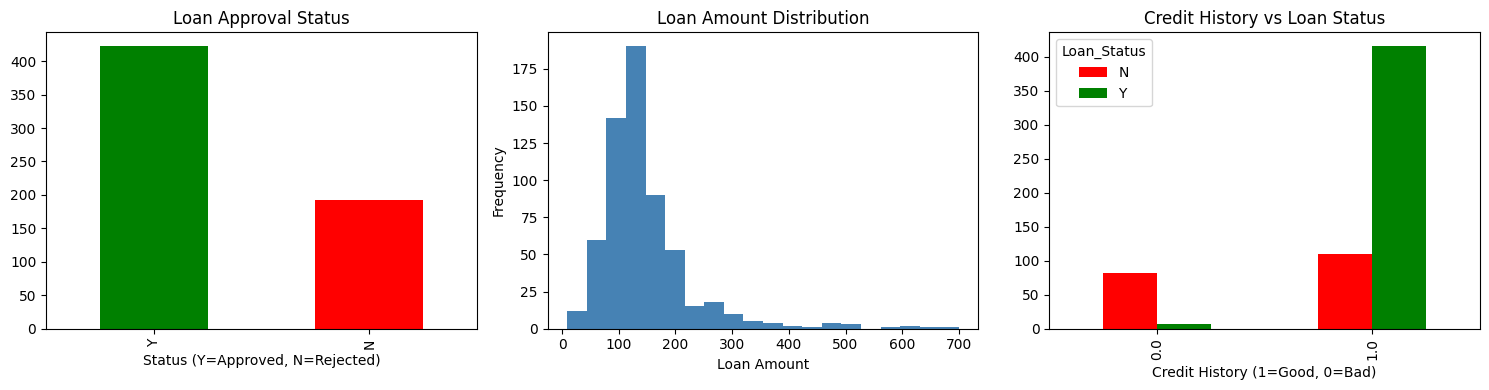

Chart saved!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loan Status
df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0],
    color=['green','red'])
axes[0].set_title('Loan Approval Status')
axes[0].set_xlabel('Status (Y=Approved, N=Rejected)')

# Loan Amount Distribution
df['LoanAmount'].plot(kind='hist', ax=axes[1], color='steelblue', bins=20)
axes[1].set_title('Loan Amount Distribution')
axes[1].set_xlabel('Loan Amount')

# Credit History vs Loan Status
pd.crosstab(df['Credit_History'], df['Loan_Status']).plot(
    kind='bar', ax=axes[2], color=['red','green'])
axes[2].set_title('Credit History vs Loan Status')
axes[2].set_xlabel('Credit History (1=Good, 0=Bad)')

plt.tight_layout()
plt.savefig('loan_analysis.png')
plt.show()
print("Chart saved!")

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender', 'Married', 'Dependents', 'Education',
        'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

# Drop Loan_ID (not useful)
df.drop('Loan_ID', axis=1, inplace=True)

print("Encoding done!")
df.head()

Encoding done!


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Approved', 'Approved']))

Accuracy: 78.86 %

Classification Report:
              precision    recall  f1-score   support

Not Approved       0.95      0.42      0.58        43
    Approved       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



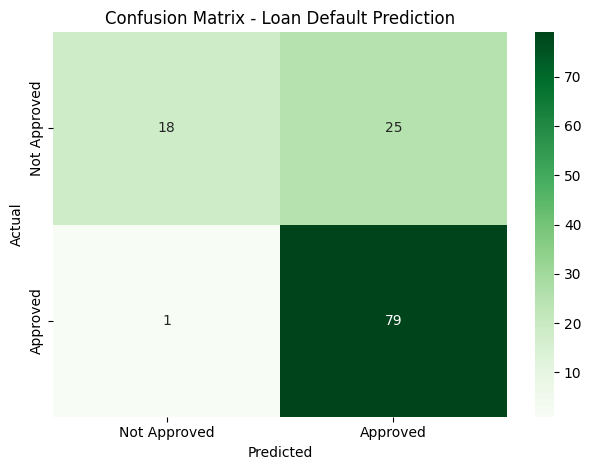

Confusion matrix saved!


In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix - Loan Default Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [13]:
print("=" * 45)
print("     LOAN DEFAULT PREDICTION - SUMMARY")
print("=" * 45)
print(f"Total records          : {len(df)}")
print(f"Training samples       : {len(X_train)}")
print(f"Testing samples        : {len(X_test)}")
print(f"Model used             : Logistic Regression")
print(f"Accuracy               : {round(accuracy_score(y_test, y_pred)*100, 2)}%")
print("=" * 45)
print("Project by: Aashritha | Finance Student")

     LOAN DEFAULT PREDICTION - SUMMARY
Total records          : 614
Training samples       : 491
Testing samples        : 123
Model used             : Logistic Regression
Accuracy               : 78.86%
Project by: Aashritha | Finance Student
